**Capítulo 2: Teoría del Entrelazamiento y Umbrales** $K_{\min}^\pm$

**Bloque 1: El Desperdicio del Origen (Motivación)**

En los métodos de criba tradicionales, evaluar múltiplos desde el principio para cada nuevo número primo genera una enorme cantidad de cálculos redundantes. El algoritmo de proyección modular resuelve este problema calculando un punto de entrada dinámico en la red espacial para cada primo.

Si comenzamos a tachar múltiplos de un primo $p$ (por ejemplo, $p=17$) partiendo desde el índice posicional inicial $k=1$, estaremos evaluando compuestos como $17 \times 5$ o $17 \times 7$. Estos compuestos ya fueron descubiertos y aniquilados por los primos $5$ y $7$ en etapas anteriores de la criba. El primer múltiplo útil e inédito de cualquier primo $p$ es siempre su cuadrado, $p^2$. El espacio de índices posicionales inferior a la posición de $p^2$ constituye una zona de redundancia matemática.



In [1]:
import pandas as pd

def calcular_redundancia(primos_base):
    resultados = []

    for p in primos_base:
        if p <= 3: continue

        # El primer compuesto verdaderamente inédito de p es p^2
        p_cuadrado = p * p

        # ¿En qué índice k cae p^2?
        # Como gcd(p, 6) = 1, p^2 siempre es congruente con 1 mod 6
        k_util = p_cuadrado // 6

        # ¿Cuántos índices k se evaluaron innecesariamente si empezamos desde k=1?
        indices_desperdiciados = k_util - 1

        resultados.append({
            "Primo Base (p)": p,
            "Primer Compuesto Inédito (p²)": p_cuadrado,
            "Índice Útil de Entrada (k_min)": k_util,
            "Índices k Desperdiciados": indices_desperdiciados
        })

    return pd.DataFrame(resultados)

# Evaluamos la redundancia para primos crecientes
primos_test = [5, 7, 13, 19, 31, 101]
df_redundancia = calcular_redundancia(primos_test)

print("=" * 75)
print(" ANÁLISIS DE REDUNDANCIA: EMPEZAR A CIBAR DESDE EL ORIGEN (k=1)")
print("=" * 75)
print(df_redundancia.to_string(index=False))
print("-" * 75)
print("Conclusión: Sin un umbral de inicio dinámico, el 99% del esfuerzo")
print("computacional en primos grandes se gasta en índices ya resueltos.")
print("=" * 75)

 ANÁLISIS DE REDUNDANCIA: EMPEZAR A CIBAR DESDE EL ORIGEN (k=1)
 Primo Base (p)  Primer Compuesto Inédito (p²)  Índice Útil de Entrada (k_min)  Índices k Desperdiciados
              5                             25                               4                         3
              7                             49                               8                         7
             13                            169                              28                        27
             19                            361                              60                        59
             31                            961                             160                       159
            101                          10201                            1700                      1699
---------------------------------------------------------------------------
Conclusión: Sin un umbral de inicio dinámico, el 99% del esfuerzo
computacional en primos grandes se gasta en índices ya resu

**Bloque 2: Calculadora Interactiva de Umbrales** $K_{\min}^\pm$

Para evitar el desperdicio computacional demostrado en el Bloque 1, el algoritmo determina analíticamente los puntos de entrada exactos para cada canal modular. Dado que todo cuadrado de un número coprimo con $6$ pertenece invariablemente al canal $\mathcal{C}_1$ ($p^2 \equiv 1 \pmod 6$), este primer choque no nos proporciona el punto de entrada para el canal opuesto $\mathcal{C}_5$.

Para encontrar el primer compuesto en el canal opuesto, necesitamos la **Teoría del Entrelazamiento Primo-Coprimo**. Se debe multiplicar $p$ por el menor primo disponible en la clase residual opuesta, denominado **Coprimo Posicional** ($\mathrm{NextKop}$).

* **Umbral** $\mathrm{Kmin}^+$: Controla la entrada en $\mathcal{C}_1$. Deriva directamente de $p^2$.
* **Umbral** $\mathrm{Kmin}^-$: Controla la entrada en $\mathcal{C}_5$. Deriva del producto cruzado $p \times \mathrm{Cop}(p)$.


In [2]:
import ipywidgets as widgets
from IPython.display import HTML, display

def es_primo(n):
    if n <= 1: return False
    if n <= 3: return True
    if n % 2 == 0 or n % 3 == 0: return False
    for i in range(5, int(n**0.5) + 1, 6):
        if n % i == 0 or n % (i + 2) == 0:
            return False
    return True

def encontrar_coprimo_posicional(p, k_p, canal_p):
    """Encuentra el menor primo en el canal opuesto con k >= k_p"""
    k_test = k_p
    while True:
        # El coprimo debe estar en el canal opuesto
        N_candidato = 6 * k_test + 1 if canal_p == "C5" else 6 * k_test - 1
        if es_primo(N_candidato):
            return N_candidato, k_test
        k_test += 1

def calcular_umbrales(p):
    if not es_primo(p) or p <= 3:
        return "<b style='color: #f38ba8;'>Ingrese un número primo p > 3.</b>"

    mod = p % 6
    canal_p = "C1" if mod == 1 else "C5"
    eps_p = 1 if mod == 1 else -1
    k_p = p // 6 if canal_p == "C1" else (p + 1) // 6

    # Buscar el Coprimo Posicional (NextKop)
    coprimo, k_kop = encontrar_coprimo_posicional(p, k_p, canal_p)
    canal_kop = "C1" if canal_p == "C5" else "C5"

    # Fórmulas algebraicas del Teorema 3.7
    if eps_p == -1: # Canal C5
        kmin_plus = p * k_p - k_p
        kmin_minus = p * k_kop + k_p
    else:           # Canal C1
        kmin_plus = p * k_p + k_p
        kmin_minus = p * k_kop - k_p

    N_kmin_plus = 6 * kmin_plus + 1
    N_kmin_minus = 6 * kmin_minus - 1

    return f"""
    <div style='padding: 16px; background-color: #1e1e2e; border-left: 4px solid #a6e3a1; border-radius: 6px; font-family: monospace; color: #cdd6f4;'>
        <h3 style='margin-top: 0; color: #a6e3a1;'>Análisis de Entrelazamiento para p = {p}</h3>
        <b>Canal del Primo:</b> {canal_p} (k_p = {k_p})<br><br>

        <b style='color: #38bdf8;'>[Canal C₁ (6k+1)] Umbral Kmin⁺</b><br>
        • Se origina del cuadrado: p² = {p} × {p} = {p**2}<br>
        • Índice Posicional de Entrada (Kmin⁺) = <b style='color: #a6e3a1;'>{kmin_plus}</b><br>
        • Verificación en red: 6({kmin_plus}) + 1 = {N_kmin_plus} <br><br>

        <b style='color: #a855f7;'>[Canal C₅ (6k-1)] Umbral Kmin⁻</b><br>
        • Coprimo Posicional (Canal {canal_kop}): {coprimo} (NextKop = {k_kop})<br>
        • Se origina del producto cruzado: {p} × {coprimo} = {p * coprimo}<br>
        • Índice Posicional de Entrada (Kmin⁻) = <b style='color: #a6e3a1;'>{kmin_minus}</b><br>
        • Verificación en red: 6({kmin_minus}) - 1 = {N_kmin_minus}
    </div>
    """

entrada_primo = widgets.IntText(
    value=11,
    description="Primo base p:",
    style={"description_width": "initial"}
)
salida_umbrales = widgets.Output()

def actualizar_umbrales(change):
    with salida_umbrales:
        salida_umbrales.clear_output()
        display(HTML(calcular_umbrales(change["new"])))

entrada_primo.observe(actualizar_umbrales, names="value")

display(entrada_primo, salida_umbrales)
with salida_umbrales:
    display(HTML(calcular_umbrales(11)))

IntText(value=11, description='Primo base p:', style=DescriptionStyle(description_width='initial'))

Output()

# Bloque 3: Visualizador del Entrelazamiento Cruzado y la "Distancia Hueca"

El uso de la cota global $p \le \sqrt{N}$ en la algoritmia clásica esconde una ineficiencia fundamental al ignorar la asimetría topológica de la red modular.

Mientras que el primer compuesto generado por un primo $p$ en su propio canal de cuadratura sí corresponde exactamente a $p^2$ (nuestro umbral $K_{\min}^+$), el primer impacto en el **canal opuesto** ($K_{\min}^-$) siempre ocurre más adelante en el espacio de índices. Este impacto cruzado nace del producto $p \times \mathrm{Cop}(p)$. Dado que el coprimo posicional $\mathrm{Cop}(p)$ es siempre un primo estrictamente mayor que $p$, se genera una **distancia hueca** en la red.

*   **Punto de Impacto Local ($K_{\min}^+$):** Equivale a la cota clásica $p^2$.
*   **Punto de Impacto Cruzado ($K_{\min}^-$):** Generado por el entrelazamiento $p \times \mathrm{Cop}(p)$.
*   **La Distancia Hueca:** La brecha $\Delta K = K_{\min}^- - K_{\min}^+$.

Cualquier algoritmo que utilice $p^2$ como único punto de entrada unificado estará desperdiciando ciclos de CPU buscando colisiones cruzadas en esta "zona muerta" donde es matemáticamente imposible que existan. El siguiente código visualiza esta asimetría y el ahorro directo que proporcionan los umbrales independientes.

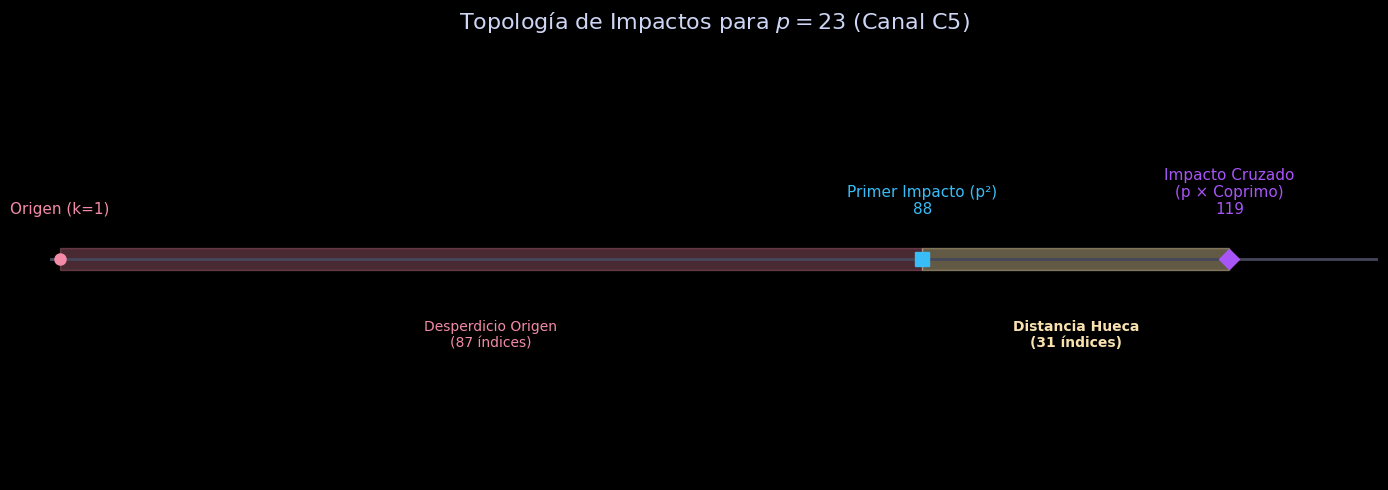

 ANÁLISIS DE ASIMETRÍA PARA p = 23 (Canal C5)
 • Coprimo posicional encontrado : 31 (Canal opuesto)
 • Impacto Local (p²)            : 23 × 23 = 529 (Índice k = 88)
 • Impacto Cruzado (p × Coprimo) : 23 × 31 = 713 (Índice k = 119)
 • DISTANCIA HUECA (Ahorro extra): 31 iteraciones omitidas en el canal opuesto.
Un límite global de raíz cuadrada evaluaría el canal opuesto desde el índice
88, desperdiciando ciclos inútilmente. Los umbrales Kmin⁺ y Kmin⁻ evitan esto.


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

# Funciones auxiliares
def es_primo(n):
    if n <= 1: return False
    if n <= 3: return True
    if n % 2 == 0 or n % 3 == 0: return False
    for i in range(5, int(n**0.5) + 1, 6):
        if n % i == 0 or n % (i + 2) == 0: return False
    return True

def obtener_entrelazamiento(p):
    mod = p % 6
    canal_p = "C1" if mod == 1 else "C5"
    eps_p = 1 if mod == 1 else -1
    k_p = p // 6 if canal_p == "C1" else (p + 1) // 6

    # Buscar Coprimo Posicional
    k_test = k_p
    while True:
        N_cand = 6 * k_test + 1 if canal_p == "C5" else 6 * k_test - 1
        if es_primo(N_cand):
            coprimo, k_kop = N_cand, k_test
            break
        k_test += 1

    if eps_p == -1: # p en C5
        kmin_plus = p * k_p - k_p
        kmin_minus = p * k_kop + k_p
    else:           # p en C1
        kmin_plus = p * k_p + k_p
        kmin_minus = p * k_kop - k_p

    return k_p, canal_p, coprimo, k_kop, kmin_plus, kmin_minus

# --- EJECUCIÓN VISUAL ---
p_eval = 23 # Primo base para la visualización

k_p, canal_p, coprimo, k_kop, kmin_plus, kmin_minus = obtener_entrelazamiento(p_eval)
distancia_hueca = abs(kmin_minus - kmin_plus)

# Ordenar umbrales para graficar correctamente de izquierda a derecha
k_min_primer = min(kmin_plus, kmin_minus)
k_min_segundo = max(kmin_plus, kmin_minus)

plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(14, 5))

# Eje principal de índices k
ax.axhline(0, color="#45475a", linewidth=2)

# Marcas principales
ax.plot(1, 0, marker="o", color="#f38ba8", markersize=8)
ax.text(1, 0.2, "Origen (k=1)", color="#f38ba8", ha="center", fontsize=11)

ax.plot(k_min_primer, 0, marker="s", color="#38bdf8", markersize=10)
ax.text(k_min_primer, 0.2, f"Primer Impacto (p²)\n{k_min_primer}", color="#38bdf8", ha="center", fontsize=11)

ax.plot(k_min_segundo, 0, marker="D", color="#a855f7", markersize=10)
ax.text(k_min_segundo, 0.2, f"Impacto Cruzado\n(p × Coprimo)\n{k_min_segundo}", color="#a855f7", ha="center", fontsize=11)

# Zona de Redundancia del Origen
rect_origen = patches.Rectangle((1, -0.05), k_min_primer - 1, 0.1, fill=True, color="#f38ba8", alpha=0.3)
ax.add_patch(rect_origen)
ax.text((1 + k_min_primer)/2, -0.4, f"Desperdicio Origen\n({k_min_primer - 1} índices)", color="#f38ba8", ha="center", fontsize=10)

# Zona de Distancia Hueca (Asimetría Quiral)
rect_hueco = patches.Rectangle((k_min_primer, -0.05), distancia_hueca, 0.1, fill=True, color="#f9e2af", alpha=0.4)
ax.add_patch(rect_hueco)
ax.text((k_min_primer + k_min_segundo)/2, -0.4, f"Distancia Hueca\n({distancia_hueca} índices)", color="#f9e2af", ha="center", fontsize=10, fontweight="bold")

# Configuración visual
ax.set_xlim(0, k_min_segundo + 15)
ax.set_ylim(-1, 1)
ax.axis("off")
ax.set_title(r"Topología de Impactos para $p = " + str(p_eval) + r"$ (Canal " + canal_p + ")", fontsize=16, color="#cdd6f4")

plt.tight_layout()
plt.show()

# Resumen en texto
print("=" * 80)
print(f" ANÁLISIS DE ASIMETRÍA PARA p = {p_eval} (Canal {canal_p})")
print("=" * 80)
print(f" • Coprimo posicional encontrado : {coprimo} (Canal opuesto)")
print(f" • Impacto Local (p²)            : {p_eval} × {p_eval} = {p_eval**2} (Índice k = {k_min_primer})")
print(f" • Impacto Cruzado (p × Coprimo) : {p_eval} × {coprimo} = {p_eval * coprimo} (Índice k = {k_min_segundo})")
print(f" • DISTANCIA HUECA (Ahorro extra): {distancia_hueca} iteraciones omitidas en el canal opuesto.")
print("=" * 80)
print("Un límite global de raíz cuadrada evaluaría el canal opuesto desde el índice")
print(f"{k_min_primer}, desperdiciando ciclos inútilmente. Los umbrales Kmin⁺ y Kmin⁻ evitan esto.")
print("=" * 80)

# Bloque 4: Construcción del Minialgoritmo Óptimo con Entrelazamiento

Hemos llegado al clímax de la Teoría de Proyección Modular. Sabemos que:
1. **No necesitamos memoria $\mathcal{O}(N)$**: Podemos saltar de índice en índice usando el Isomorfismo I.
2. **No necesitamos divisiones lentas**: Podemos usar la congruencia posicional del Isomorfismo II.
3. **No necesitamos evaluar desde cero**: Calculamos el punto de entrada exacto ($K_{\min}^\pm$) mediante el entrelazamiento primo-coprimo para saltar la "distancia hueca".

### El Algoritmo Resultante
Al unir estos principios, obtenemos un algoritmo que solo necesita "recordar" los primos menores o iguales a $\sqrt{N}$ y sus respectivos umbrales $K_{\min}$. Esto reduce la memoria de trabajo de forma drástica, logrando una complejidad espacial sublineal de $\Theta(\sqrt{N}/\log N)$.

Para cernir números hasta $N = 1,000,000$, la Criba de Eratóstenes tradicional exige un vector de 1 millón de booleanos (aprox. 1 MB). Nuestro algoritmo, en cambio, solo almacenará una pequeña lista de "generadores".

Ejecutemos la versión didáctica del algoritmo y observemos la magia de la compresión espacial en tiempo real.

In [4]:
import time

def encontrar_coprimo_posicional(k_p, canal_p, primos_base):
    """Encuentra el NextKop iterando sobre los primos base ya descubiertos"""
    for p_info in primos_base:
        if p_info['canal'] != canal_p and p_info['k'] >= k_p:
            return p_info['p'], p_info['k']
    # Si aún no existe en la base (casos iniciales), lo estimamos analíticamente
    k_test = k_p
    while True:
        cand = 6 * k_test + 1 if canal_p == 'C5' else 6 * k_test - 1
        es_p = True
        for i in range(2, int(cand**0.5) + 1):
            if cand % i == 0:
                es_p = False
                break
        if es_p: return cand, k_test
        k_test += 1

def criba_modular_didactica(k_max):
    N_max = 6 * k_max + 1
    limite_base = int(N_max**0.5)

    # Estado estático: solo guarda primos <= sqrt(N)
    primos_base = []
    conteo_primos = 2  # Incluimos el 2 y el 3 axiomáticamente

    start_time = time.time()

    for k in range(1, k_max + 1):
        # 1. EVALUACIÓN CANAL C5 (6k - 1)
        candidato_c5 = 6 * k - 1
        es_primo_c5 = True

        # Filtro rápido por terminación (Divisibilidad por 5)
        if k > 3 and (k % 10 == 1 or k % 10 == 6):
            es_primo_c5 = False
        else:
            for p_info in primos_base:
                if k < p_info['kmin_minus']:
                    continue # Salto topológico (Kmin aplicado)

                # Regla posicional
                if p_info['eps'] == -1: # Mismo canal
                    if (k - p_info['k']) % p_info['p'] == 0:
                        es_primo_c5 = False; break
                else: # Canal opuesto
                    if (k + p_info['k']) % p_info['p'] == 0:
                        es_primo_c5 = False; break

        if es_primo_c5:
            conteo_primos += 1
            if candidato_c5 <= limite_base:
                coprimo, k_kop = encontrar_coprimo_posicional(k, 'C5', primos_base)
                kmin_plus = candidato_c5 * k - k
                kmin_minus = candidato_c5 * k_kop + k
                primos_base.append({'p': candidato_c5, 'k': k, 'eps': -1, 'canal': 'C5',
                                    'kmin_plus': kmin_plus, 'kmin_minus': kmin_minus})

        # 2. EVALUACIÓN CANAL C1 (6k + 1)
        candidato_c1 = 6 * k + 1
        es_primo_c1 = True

        # Filtro rápido por terminación
        if k > 3 and (k % 10 == 4 or k % 10 == 9):
            es_primo_c1 = False
        else:
            for p_info in primos_base:
                if k < p_info['kmin_plus']:
                    continue # Salto topológico

                # Regla posicional
                if p_info['eps'] == 1: # Mismo canal
                    if (k - p_info['k']) % p_info['p'] == 0:
                        es_primo_c1 = False; break
                else: # Canal opuesto
                    if (k + p_info['k']) % p_info['p'] == 0:
                        es_primo_c1 = False; break

        if es_primo_c1:
            conteo_primos += 1
            if candidato_c1 <= limite_base:
                coprimo, k_kop = encontrar_coprimo_posicional(k, 'C1', primos_base)
                kmin_plus = candidato_c1 * k + k
                kmin_minus = candidato_c1 * k_kop - k
                primos_base.append({'p': candidato_c1, 'k': k, 'eps': 1, 'canal': 'C1',
                                    'kmin_plus': kmin_plus, 'kmin_minus': kmin_minus})

    tiempo = time.time() - start_time
    return conteo_primos, len(primos_base), tiempo

# Ejecución del experimento
k_objetivo = 166_666  # Equivale a N = 1,000,000 (aprox)
N_real = 6 * k_objetivo + 1

print("=" * 70)
print(f" CRIBADO MODULAR CON ENTRELAZAMIENTO HASTA N ≈ 1,000,000")
print("=" * 70)
total_primos, num_primos_base, t_exec = criba_modular_didactica(k_objetivo)

print(f" • Límite Evaluado (N) : {N_real}")
print(f" • Primos Encontrados  : {total_primos} (Exacto: 78,498)")
print(f" • Primos en Memoria   : {num_primos_base} (Estado dinámico)")
print(f" • Memoria Estimada    : {num_primos_base * 24} bytes (~ {num_primos_base * 24 / 1024:.2f} KB)")
print(f" • Tiempo de Ejecución : {t_exec:.3f} segundos")
print("=" * 70)
print(f"COMPRESIÓN DE MEMORIA: En lugar de guardar 1,000,000 de booleanos,")
print(f"el algoritmo solo almacena los {num_primos_base} primos generadores clave.")
print("=" * 70)

 CRIBADO MODULAR CON ENTRELAZAMIENTO HASTA N ≈ 1,000,000
 • Límite Evaluado (N) : 999997
 • Primos Encontrados  : 78498 (Exacto: 78,498)
 • Primos en Memoria   : 166 (Estado dinámico)
 • Memoria Estimada    : 3984 bytes (~ 3.89 KB)
 • Tiempo de Ejecución : 3.389 segundos
COMPRESIÓN DE MEMORIA: En lugar de guardar 1,000,000 de booleanos,
el algoritmo solo almacena los 166 primos generadores clave.


### Formulario de Criba Modular: Geometría Posicional y Umbrales de Entrelazamiento

**1. Isomorfismo Posicional (Reglas de Colisión)**
Para evaluar si un candidato $N = 6k \pm 1$ es divisible por un primo base $p = 6k_p \pm 1$, se aplica la siguiente regla de congruencia sobre el índice $k$:

*   **Mismo Canal Modular** (ej. $N \in \mathcal{C}_5$ y $p \in \mathcal{C}_5$): El candidato es compuesto si $k \equiv k_p \pmod p$ (con $k > k_p$).
*   **Canales Modulares Opuestos** (ej. $N \in \mathcal{C}_5$ y $p \in \mathcal{C}_1$): El candidato es compuesto si $k \equiv -k_p \pmod p$.

**2. Umbrales de Activación Asimétrica ($K_{\min}^\pm$)**
El primer múltiplo de un primo $p$ en cada canal no se busca desde el origen, sino en los siguientes índices exactos de impacto. Sea $\mathrm{NextKop}(p)$ el índice del Coprimo Posicional (el menor primo en el canal opuesto con $k \ge k_p$):

| Caso Primo Base | Impacto Local en $\mathcal{C}_1$ ($K_{\min}^+$) | Impacto Cruzado en $\mathcal{C}_5$ ($K_{\min}^-$) |
| :--- | :--- | :--- |
| **$p \in \mathcal{C}_5$** ($p = 6k_p - 1$) | $p \cdot k_p - k_p$ | $p \cdot \mathrm{NextKop}(p) + k_p$ |
| **$p \in \mathcal{C}_1$** ($p = 6k_p + 1$) | $p \cdot k_p + k_p$ | $p \cdot \mathrm{NextKop}(p) - k_p$ |

*   **Origen de $K_{\min}^+$**: Deriva analíticamente del cuadrado $p^2$. Como todo cuadrado de un número coprimo con $6$ es congruente con $1 \pmod 6$, este impacto pertenece invariablemente al canal $\mathcal{C}_1$.
*   **Origen de $K_{\min}^-$**: Deriva analíticamente del producto entrelazado $p \times \mathrm{Cop}(p)$. Al multiplicar dos primos de canales opuestos (o un primo por sí mismo si la lógica se invierte), el resultado siempre aterriza en el canal $\mathcal{C}_5$.